# Дерево решения

Деревья решения основаны на известной структуре данных - деревьях, которые по сути представляют собой последовательные инструкции с условиями. Например, в задаче согласования кредита может быть следующий алгоритм принятия решения:

1. Старше ли клиент 18 лет? Если да, то продолжаем, иначе отказываем в кредите.

2. Превышает ли его заработок 50 тысяч рублей? Если да, то продолжаем, иначе отказываем в кредите.

3. Были ли у клиента просроченные кредиты ранее? Если да, отказываем в кредите, иначе выдаем.

В листьях (терминальных, конечных узлах или конечных вершинах) деревьев стоят значения целевой функции (прогноз), а в узлах - условия перехода, определяющие, по какому из рёбер идти. Если речь идет о бинарных деревьях (каждый узел производит ветвление на две части), обычно, если условие в узле истинно, то происходит переход по левому ребру, если ложно, то по правому.

In [138]:
# визуализировать дерево можно посредством библиотеки python-graphviz
from graphviz import Digraph

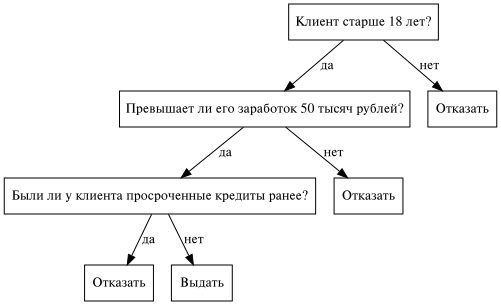

In [139]:
dot = Digraph(node_attr={'shape': 'box'})

dot.node('A', label='Клиент старше 18 лет?')
dot.node('B', label='Превышает ли его заработок 50 тысяч рублей?')
dot.node('C', label='Отказать')
dot.node('D', label='Были ли у клиента просроченные кредиты ранее?')
dot.node('E', label='Отказать')
dot.node('F', label='Отказать')
dot.node('G', label='Выдать')

dot.edge('A', 'B', label='да')
dot.edge('A', 'C', label='нет')
dot.edge('B', 'D', label='да')
dot.edge('B', 'E', label='нет')
dot.edge('D', 'F', label='да')
dot.edge('D', 'G', label='нет')

dot

В задачах машинного обучения чаще всего в вершинах прописываются максимально простые условия. Обычно это сравнение значения одного из признаков $x^{j}$ с некоторым заданным порогом $t$:

$$[x^{j} \leq t].$$

Если выполняется задача классификации, конечным прогнозом считается класс или распределение вероятностей классов. В случае регрессии прогноз в листе представляет собой вещественное число.

Большим плюсом деревьев считается тот факт, что они легко интерпретируемы. То есть вы всегда можете восстановить всю цепочку принятия решения алгоритмом, в отличии от любых более сложных методов, таких, как нейронные сети.

Главное же отрицательное качество дерево решения - они (деревья) очень легко переобучаются. Легко построить дерево, где каждый лист будет соответствовать одному объекту обучающей выборки. Оно будет идеально подогнано под обучающую выборку, давать стопроцентный ответ на ней, но при этом не станет восстанавливать оригинальных закономерностей, и качество ответов на новых данных окажется неудовлетворительным.

## Теория построения дерева решения

В машинном обучении деревья строятся от корня к листьям. Вначале выбирается корень и критерий, по которому выборка разбивается пополам (или на несколько частей). Затем то же самое делается для каждого из потомков этого корня и так далее до остановки. Задача на каждом этапе состоит в выборе способа разбиения каждого узла, то есть в выборе значения порога, с которым будет сравниваться значение одного из признаков в каждом узле.

Разбиениение происходит на основании заранее заданного функционала качества $Q(X, j, t)$. Находятся наилучшие значения $j$ и $t$ для выбора порога $[x^{j}<t]$. Параметры $j$ и $t$ можно выбирать перебором: признаков конечное число, а из всех возможных значений порога $t$ можно рассматривать только те, при которых получаются различные разбиения на две подвыборки. Таким образом, различных значений параметра $t$ будет столько же, сколько различных значений признака $x^{j}$ в обучающей выборке.

В каждой потенциальной вершине производится проверка, не выполнилось ли некоторое условие останова. Если оно выполнилось, разбиение прекращается, такая вершина будет содержать прогноз.

В задаче классификации это будет класс, к которому относится большая часть объектов из выборки в листе $X_{m}$

$$a_{m} = \text{argmax}_{y \in Y} \sum_{i \in X_{m}}[y_{i}=y]$$

или доля объектов определённого класса $k$, если требуется предсказать вероятности классов

$$a_{mk} = \frac{1}{|X_{m}|} \sum_{i \in X_{m}}[y_{i}=k].$$

В случае регрессии в качестве ответа можно давать средние значение по выборке по выборке в листе

$$a_{m} = \frac{1}{|X_{m}|} \sum_{i \in X_{m}}y_{i}.$$

За функционал качества при работе с деревом решений принимается функционал вида:

$$Q(X_{m}, j, t) = H(X_{m}) - \frac{|X_{l}|}{|X_{m}|}H(X_{l}) - \frac{|X_{r}|}{|X_{m}|}H(X_{r}),$$

где $X_{m}$ — множество объектов, попавших в лист на этом шаге, а $X_{l}$ и $X_{r}$ — множества, попадающие в левое и правое поддерево, соответственно, после гипотетического разбиения. $H(X)$ — _критерий информативности_. Он оценивает качество распределения объектов в подмножестве и тем меньше, чем меньше разнообразие ответов в $X$, соответственно, задача обучения состоит в его минимизации и максимизации $Q(X_{m}, j, t)$ на этом шаге.

### Критерий информативности

В случае регрессии разброс будет характретизваться дисперсией, поэтому критерий информативности будет записан в виде

$$H(X) = \frac{1}{X}\sum_{i\in X}(y_{i} - \bar{y}(X))^{2}.$$

В задаче классификации есть несколько способов определить критерий информативности.

Обозначим через $p_{k}$ долю объектов класса $k$ в выборке $X$:

$$p_{k} = \frac{1}{|X|}\sum_{i\in X}[y_{i} = k].$$

$p_{k}$ будет характеризовать вероятность выдачи класса $k$.

_Критерий Джини_, или _индекс Джини_, выглядит следующим образом:

$$H(X) = \sum^{K}_{k=1}p_{k}(1-p_{k}),$$

где $K$ — количество классов в наборе данных $X$.

Его минимум достигается, когда все объекты в подмножестве относятся к одному классу, а максимум — при равном содержании объектов всех классов. Критерий информативности Джини можно интерпретировать как вероятность ошибки случайного классификатора.

Ещё один критерий информативности — _энтропийный критерий_. Он также называется _энтропией Шеннона_ и записывается как

$$H(X) = - \sum^{K}_{k=1}p_{k}\text{log}_{2}p_{k}.$$

Минимум энтропии также достигается, когда все объекты относятся к одному классу, а максимум — при равномерном распределении. Прирост информации есть утрата неопределённости (=уменьшение энтропии). В формуле полагается, что $0\text{log}_{2}0=0.$

### Остановка построения дерева

_Критерии останова_ — это критерий, который показывает, надо ли остановить процесс построения дерева. Правильный выбор критериев останова, относящихся к росту дерева, может существенно повлиять на его качество. Существует множество возможных ограничений:

- Ограничение максимальной глубины дерева. Этот критерий считается довольно грубым, но хорошо зарекомендовавшим себя в построении композиций деревьев — когда несколько деревьев объединяются в один алгоритм.


- Ограничение максимального количества листьев.


- Ограничение минимального количества $n$ объектов в листе. Оно должно быть достаточным, чтобы построить надёжный прогноз.


- Останов, когда все объекты в листе относятся к одному классу.

- Требование улучшения функционала качества при разбиении на какую-то минимальную величину.

In [140]:
import matplotlib.pyplot as plt
import random

from matplotlib.colors import ListedColormap
from sklearn import datasets

import numpy as np

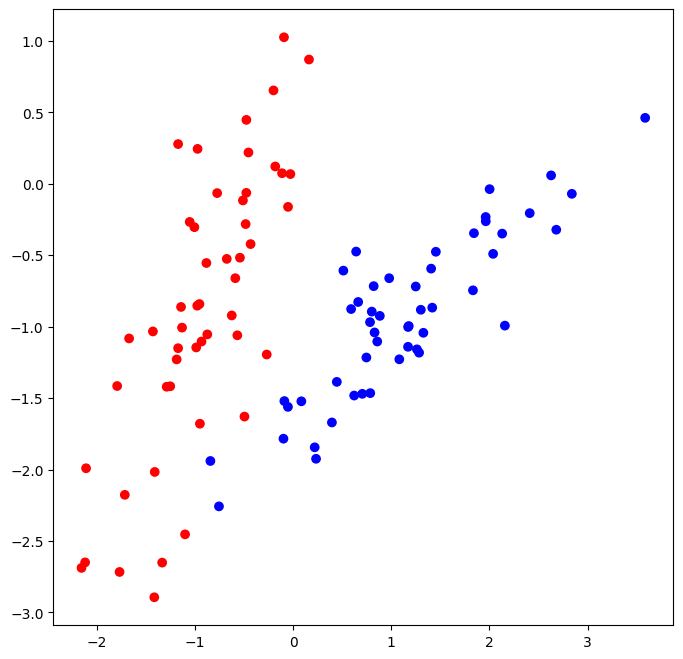

In [141]:
# сгенерируем и визуализируем данные
classification_data, classification_labels = datasets.make_classification(n_features = 2, n_informative = 2,
                                                      n_classes = 2, n_redundant=0,
                                                      n_clusters_per_class=1, random_state=5)

colors = ListedColormap(['red', 'blue'])
light_colors = ListedColormap(['lightcoral', 'lightblue'])

plt.figure(figsize=(8,8))
plt.scatter(list(map(lambda x: x[0], classification_data)), list(map(lambda x: x[1], classification_data)),
              c=classification_labels, cmap=colors)
plt.show()

In [142]:
class Tree:
    class Node:
        def __init__(self, index, t, true_branch, false_branch):
            self.index = index  # индекс признака, по которому ведётся сравнение с порогом в этом узле
            self.t = t  # значение порога
            self.true_branch = true_branch  # поддерево, удовлетворяющее условию в узле
            self.false_branch = false_branch  # поддерево, не удовлетворяющее условию в узле
        
        def forward(self, obj):
            from numbers import Number
            if isinstance(obj[self.index], Number):
                return self.true_branch.forward(obj) if obj[self.index] <= self.t else self.false_branch.forward(obj)
            else:
                return self.true_branch.forward(obj) if obj[self.index] == self.t else self.false_branch.forward(obj)
    
    class Leaf:
        def __init__(self):
            self.value = None
        
        def forward(self, obj):
            return self.value

    def __init__(self, tree_depth=np.inf, min_leaf_count=1, criteria="entropy"):
        if tree_depth < 0 or min_leaf_count < 1:
            raise ValueError("tree_depth and min_leaf_count must be greater than 0")
        if criteria not in ["entropy", "gini", "missclassification"]:
            raise ValueError("criteria must be one of: entropy, gini, missclassification")

        self.tree_depth = tree_depth
        self.min_leaf_count = min_leaf_count
        self.criteria = criteria
        self.classes = None
        self.tree = None

    def fit(self, train_data, train_labels):
        self.data = train_data
        self.labels = train_labels
        self.classes = np.unique(train_labels)
        indices = np.arange(len(train_labels))
        self.tree = self.build_node(indices, self.tree_depth)

    def build_node(self, idx, depth):
        labels = self.labels[idx]

        if depth == 0 or len(idx) < self.min_leaf_count or len(np.unique(labels)) == 1:
            leaf = self.Leaf()
            leaf.value = self.calc_leaf(labels)
            return leaf

        left_idx, right_idx, index, t = self.find_best_split(idx)

        if left_idx is None or right_idx is None:
            leaf = self.Leaf()
            leaf.value = self.calc_leaf(labels)
            return leaf

        true_branch = self.build_node(left_idx, depth - 1)
        false_branch = self.build_node(right_idx, depth - 1)
        return self.Node(index, t, true_branch, false_branch)
    
    def find_best_split(self, idx):
        from numbers import Number
        data, labels = self.data, self.labels
        criteria = getattr(self, self.criteria)

        t_best = None
        index_best = None
        left_best = None
        right_best = None
        q_best = None

        n_total = len(idx)

        for feat in range(len(data[0])):
            feature_vals = [data[i][feat] for i in idx]
            unique_vals = set(feature_vals)
            if len(unique_vals) == 1:
                continue

            for t in unique_vals:
                left, right = [], []
                for i in idx:
                    v = data[i][feat]
                    if isinstance(v, Number):
                        (left if v <= t else right).append(i)
                    else:
                        (left if v == t else right).append(i)

                if len(left) == 0 or len(right) == 0:
                    continue

                left_labels = labels[left]
                right_labels = labels[right]

                p_left = np.array([np.mean(left_labels == c) for c in self.classes])
                p_right = np.array([np.mean(right_labels == c) for c in self.classes])

                imp_left = criteria(p_left)
                imp_right = criteria(p_right)

                q = (len(left) * imp_left + len(right) * imp_right) / n_total

                if q_best is None or q < q_best:
                    q_best = q
                    t_best = t
                    index_best = feat
                    left_best = left
                    right_best = right

        if left_best is None or right_best is None:
            return None, None, None, None

        return np.array(left_best), np.array(right_best), index_best, t_best
    
    def calc_leaf(self, labels):
        vals, counts = np.unique(labels, return_counts=True)
        return vals[np.argmax(counts)]
    
    def predict(self, test_data):
        predictions = []
        for obj in test_data:
            predictions.append(self.tree.forward(obj))
        return np.array(predictions)

    @staticmethod
    def missclassification(p):
        return 1 - np.max(p)

    @staticmethod
    def entropy(p):
        eps = 1e-15
        p += eps
        return -sum(p * np.log2(p))
    
    @staticmethod
    def gini(p):
        return 1 - sum(p ** 2)
    
    def visualize_tree(self):
        dot = Digraph(node_attr={'shape': 'box'})
        
        def add_node(node, node_id):

            if isinstance(node, self.Leaf):
                label = f"Class: {node.value}"
                dot.node(node_id, label=label)
                return

            label = f"X[{node.index}] <= {node.t}"
            dot.node(node_id, label=label)

            true_id = f"{node_id}T"
            add_node(node.true_branch, true_id)
            dot.edge(node_id, true_id, label="да")

            false_id = f"{node_id}F"
            add_node(node.false_branch, false_id)
            dot.edge(node_id, false_id, label="нет")

        add_node(self.tree, "root")
        return dot

In [143]:
# Разобьём выборку на обучающую и тестовую

from sklearn import model_selection

train_data, test_data, train_labels, test_labels = model_selection.train_test_split(classification_data,
                                                                                     classification_labels,
                                                                                     test_size = 0.3,
                                                                                     random_state = 1)

In [144]:
tree = Tree(tree_depth=3, min_leaf_count=5, criteria="gini")
tree.fit(train_data, train_labels)

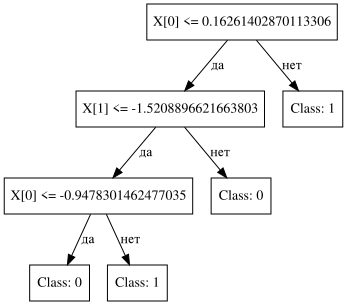

In [145]:
tree.visualize_tree()

In [146]:
# Получим ответы для обучающей выборки
train_answers = tree.predict(train_data)

In [147]:
# Получим ответы для тестовой выборки
answers = tree.predict(test_data)

In [148]:
# Введём функцию подсчёта точности
def accuracy_metric(actual, predicted):
    correct = 0
    for i in range(len(actual)):
        if actual[i] == predicted[i]:
            correct += 1
    return correct / float(len(actual)) * 100.0

In [149]:
# Точность на обучающей выборке
train_accuracy = accuracy_metric(train_labels, train_answers)
train_accuracy

98.57142857142858

In [150]:
# Точность на тестовой выборке
test_accuracy = accuracy_metric(test_labels, answers)
test_accuracy

100.0

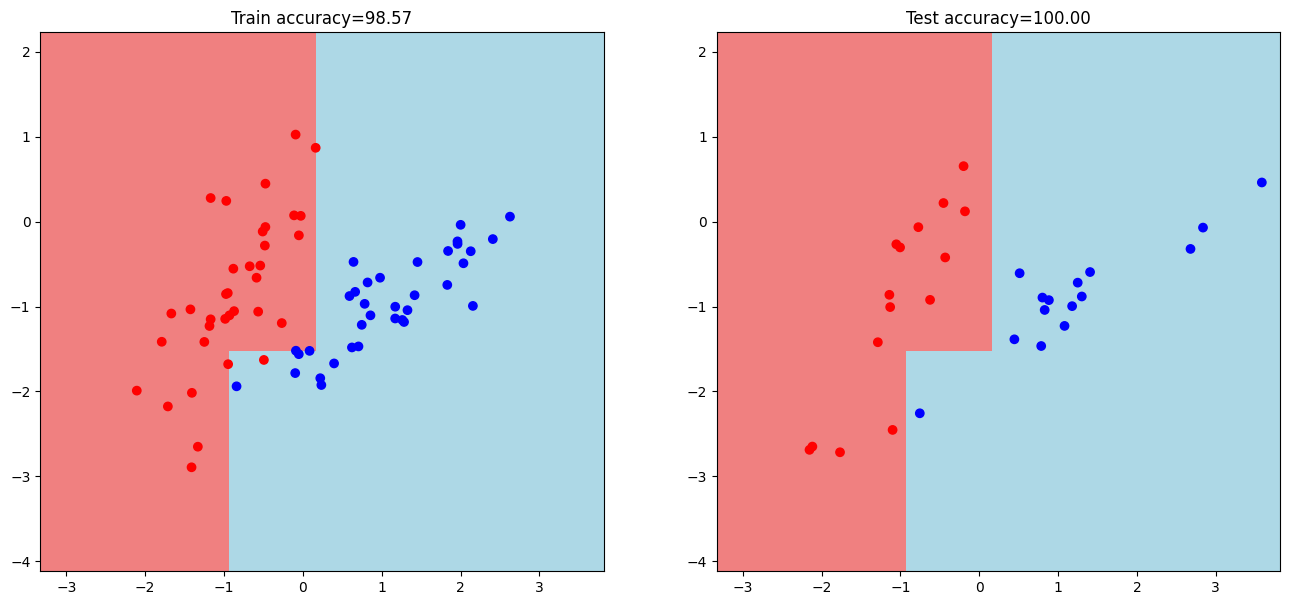

In [151]:
# Визуализируем дерево на графике

def get_meshgrid(data, step=.05, border=1.2):
    x_min, x_max = data[:, 0].min() - border, data[:, 0].max() + border
    y_min, y_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

plt.figure(figsize = (16, 7))

# график обучающей выборки
plt.subplot(1,2,1)
xx, yy = get_meshgrid(train_data)
mesh_predictions = np.array(tree.predict(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

#print(np.c_[xx.ravel(), yy.ravel()])

plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
plt.scatter(train_data[:, 0], train_data[:, 1], c = train_labels, cmap = colors)
plt.title(f'Train accuracy={train_accuracy:.2f}')

# график тестовой выборки
plt.subplot(1,2,2)
plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
plt.scatter(test_data[:, 0], test_data[:, 1], c = test_labels, cmap = colors)
plt.title(f'Test accuracy={test_accuracy:.2f}')
plt.show()
